# 04 — Feature Engineering, Selection & Train-Test Split (Stages 5–6)
Implemented in `src/feature_engineering.py` and `src/feature_study.py`. The stratified split is made first; every feature decision uses 5-fold CV on the training split only.

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))
import pandas as pd
from IPython.display import Image, display
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 30)
FIG = ROOT / 'figures'; REP = ROOT / 'reports'

In [2]:
from src.feature_engineering import ENGINEERED_FEATURES
pd.DataFrame({'formula': ENGINEERED_FEATURES})

,formula
Temp difference [K],Process temperature [K] - Air temperature [K]
Power [W],Torque [Nm] * Rotational speed [rpm] * 2*pi/60
Strain [min*Nm],Tool wear [min] * Torque [Nm]


## Stage 6 — stratified split

In [3]:
pd.read_csv(REP / 'stage5/split_summary.csv')

,class,train_count,train_%,test_count,test_%
0,No Failure,7715,96.92,1928,96.88
1,TWF,34,0.43,9,0.45
2,HDF,85,1.07,21,1.06
3,PWF,64,0.80,16,0.80
4,OSF,62,0.78,16,0.80
5,Total,7960,100.00,1990,100.00


## Engineered features by class (training split)

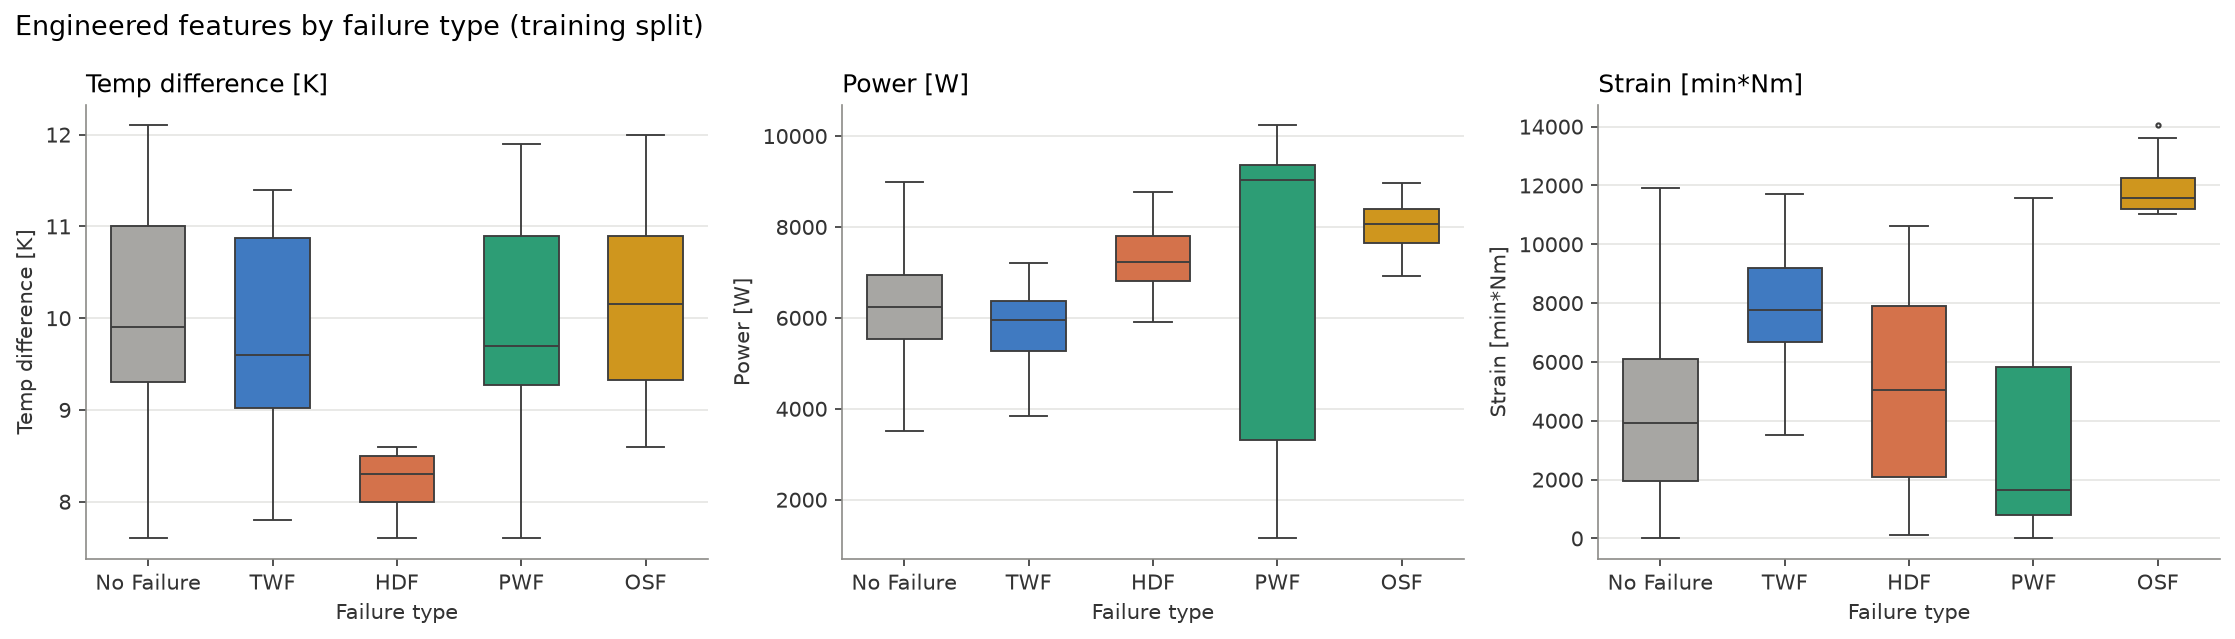

In [4]:
display(Image(filename=str(FIG / '05_engineered_features_by_class.png'), width=950))

In [5]:
pd.read_csv(REP / 'stage5/engineered_feature_medians_by_class.csv', index_col=0)

,Temp difference [K],Power [W],Strain [min*Nm]
Failure Type,,,
No Failure,9.90,6239.01,3933.60
TWF,9.60,5948.42,7752.65
HDF,8.30,7218.74,5045.60
PWF,9.70,9037.44,1632.40
OSF,10.15,8058.18,11575.15


## Redundancy check

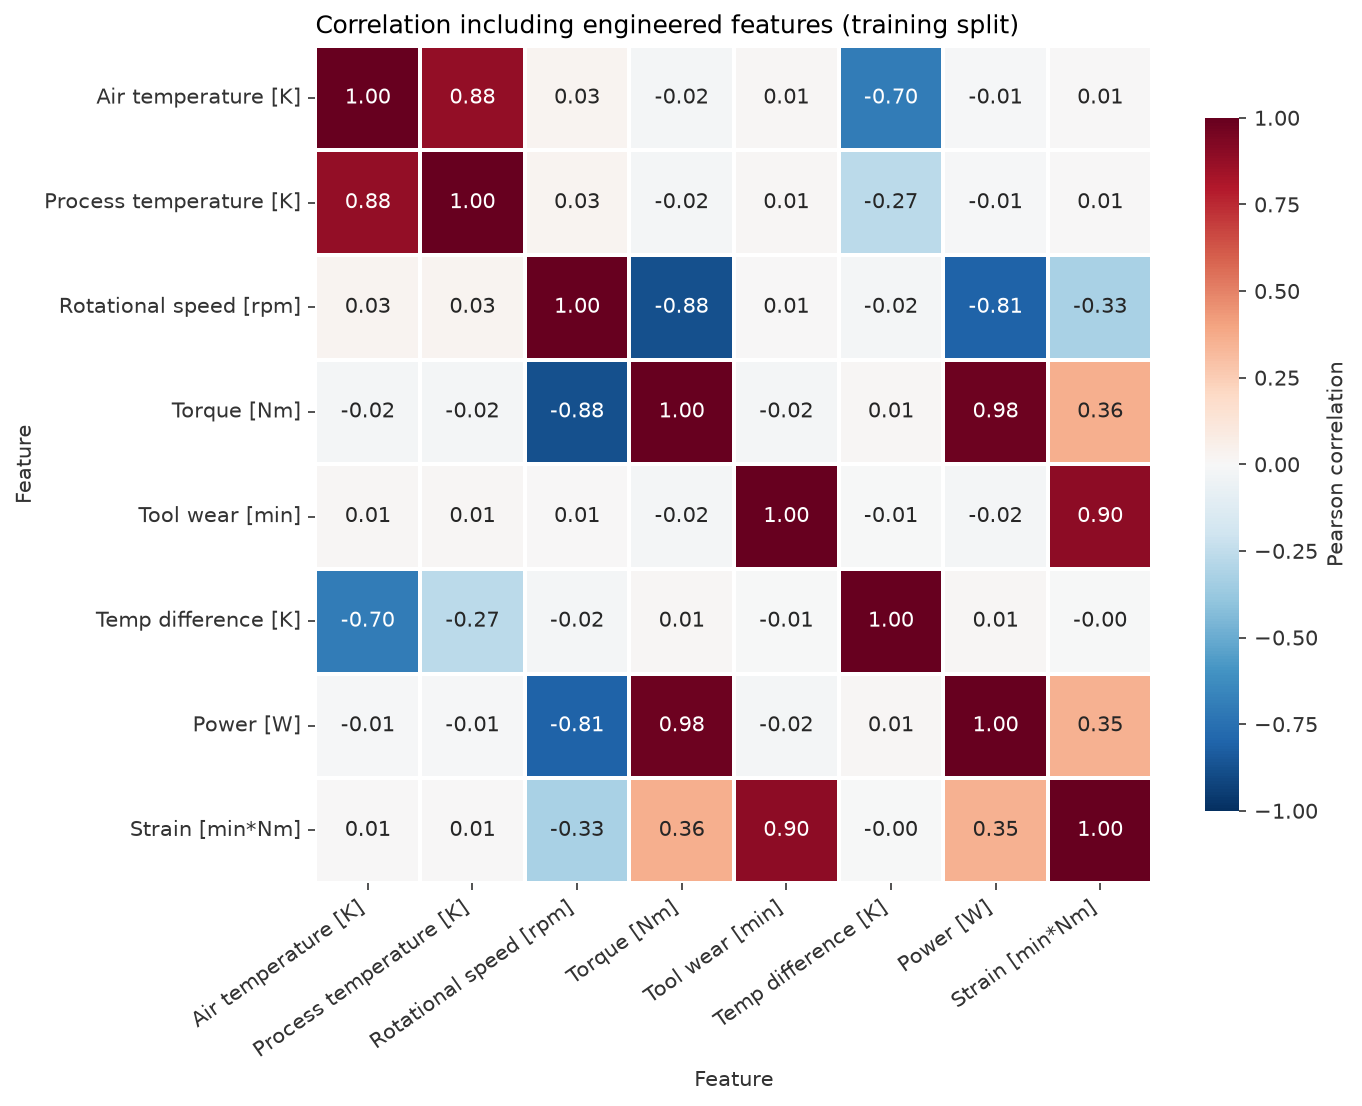

In [6]:
display(Image(filename=str(FIG / '05_correlation_with_engineered.png'), width=700))

## Mutual information (filter view)

In [7]:
pd.read_csv(REP / 'stage5/mutual_information.csv')

,feature,mutual_information
0,Power [W],0.0652
1,Torque [Nm],0.0630
2,Rotational speed [rpm],0.0516
3,Strain [min*Nm],0.0475
4,Tool wear [min],0.0300
5,Temp difference [K],0.0265
6,Air temperature [K],0.0172
7,Process temperature [K],0.0073
8,Type,0.0031


## Original vs engineered vs selected (wrapper view, 5-fold CV)

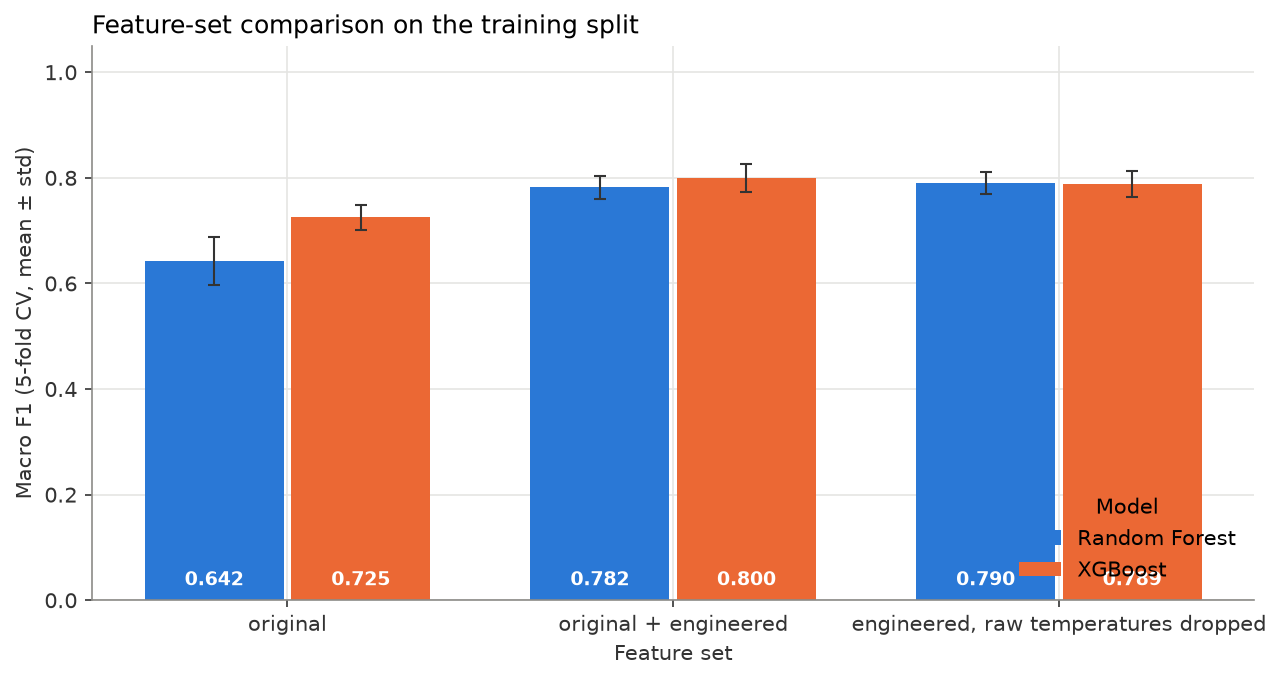

In [8]:
display(Image(filename=str(FIG / '05_feature_set_comparison.png'), width=850))

In [9]:
pd.read_csv(REP / 'stage5/feature_set_comparison.csv')

,feature_set,model,n_input_features,cv_macro_f1_mean,cv_macro_f1_std,fold_1,fold_2,fold_3,fold_4,fold_5
0,original,Random Forest,6,0.6420,0.0452,0.6999,0.6293,0.6793,0.6317,0.5698
1,original,XGBoost,6,0.7252,0.0233,0.7425,0.7193,0.7526,0.7269,0.6849
2,original + engineered,Random Forest,9,0.7821,0.0214,0.8056,0.7637,0.7869,0.8028,0.7515
3,original + engineered,XGBoost,9,0.8000,0.0261,0.7954,0.8120,0.7892,0.8411,0.7620
4,"engineered, raw temperatures dropped",Random Forest,7,0.7896,0.0211,0.7885,0.8073,0.7933,0.8086,0.7504
5,"engineered, raw temperatures dropped",XGBoost,7,0.7887,0.0247,0.7918,0.7697,0.7799,0.8350,0.7674


In [10]:
json.load(open(REP / 'stage5' / 'selected_feature_set.json'))

{'selected_feature_set': 'original + engineered',
 'params': {'add_engineered': True, 'drop_columns': []},
 'rule': 'highest 5-fold CV Macro F1 averaged over Random Forest and XGBoost',
 'mean_cv_macro_f1_by_set': {'original': 0.6836,
  'original + engineered': 0.791,
  'engineered, raw temperatures dropped': 0.7892}}